In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from loadPressureData import loadPressureData, matlab_datenum_to_datetime64
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from BulkWaveStats import detide, Spp_to_Seta, sig_wave_height
from scipy.signal import spectrogram
import pandas as pd
import xarray as xr
from Becker_eta_f import compute_eta_f

This notebook follows the computations performed on Becker(2014) *Water Level Effects on breaking wave setup for Pacific Island fringing reefs*

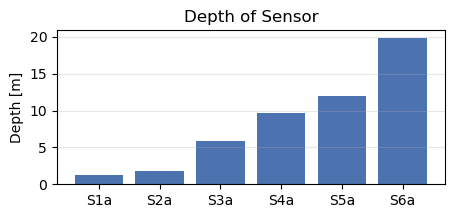

In [4]:
# need to decide where the reef flat/reef face is 
labels = ['S1a', 'S2a', 'S3a', 'S4a', 'S5a', 'S6a']
depths = [1.3, 1.74, 5.90, 9.64, 11.95, 19.9]

fig, ax = plt.subplots(figsize=(5, 2))
ax.bar(labels, depths, color="#4C72B0")
ax.set_ylabel("Depth [m]")
ax.set_title("Depth of Sensor")
ax.grid(axis="y", alpha=0.3)
plt.show()

since sensor 1 and 2 are ~same depth, i'm going to assumer that sensor 3 is the end of the reef face and sensor 6 is the "offshore" sensor but will talk to mark about that. 

In [14]:
### ------------------ LOAD, DETIDE DATA, COMPUTE S_ETA -------------------- ###

# INPUT VALUES
fs = 1
nperseg = 7200 # 2 hr windows
noverlap = nperseg * 0.75 # 75% overlap
LAT = 21.58055556

## ----- Sensor 1 (NEARSHORE)----- ##
bursts1 = loadPressureData(Path("data/MoA18411.mat"))
t1, h1, p1 = bursts1.time, bursts1.depth_m, bursts1.pressure_pa
# detide
tide1, p1_detide, p1_raw = detide(p1, t1, LAT = LAT)
# PSD of eta
freqs1, t1_spec, Spp1 = spectrogram(p1_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta1, t_eta1, h_eta1 = Spp_to_Seta(Spp1, freqs1, t1_spec, t1, h1)

## ----- Sensor 4/5 (REEF FACE)----- ##
bursts4 = loadPressureData(Path("data/MoA48411.mat"))
t4, h4, p4 = bursts4.time, bursts4.depth_m, bursts4.pressure_pa
# detide
tide4, p4_detide, p4_raw = detide(p4, t4, LAT = LAT)
# PSD of eta
freqs4, t4_spec, Spp4 = spectrogram(p4_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta4, t_eta4, h_eta4 = Spp_to_Seta(Spp4, freqs4, t4_spec, t4, h4)

bursts4b = loadPressureData(Path("data/MoB48411.mat"))
t4b, h4b, p4b = bursts4b.time, bursts4b.depth_m, bursts4b.pressure_pa
# detide
tide4b, p4b_detide, p4b_raw = detide(p4b, t4b, LAT = LAT)
# PSD of eta
freqs4b, t4b_spec, Spp4b = spectrogram(p4b_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta4b, t_eta4b, h_eta4b = Spp_to_Seta(Spp4b, freqs4b, t4b_spec, t4b, h4b)

bursts5 = loadPressureData(Path("data/MoA58411.mat"))
t5, h5, p5 = bursts5.time, bursts5.depth_m, bursts5.pressure_pa
# detide
tide5, p5_detide, p5_raw = detide(p5, t5,  LAT = LAT)
freqs5, t5_spec, Spp5 = spectrogram(p5_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta5, t_eta5, h_eta5 = Spp_to_Seta(Spp5, freqs5, t5_spec, t5, h5)

## ----- Sensor 6 (OFFSHORE)----- ##
bursts6 = loadPressureData(Path("data/MoA68411.mat"))
t6, h6, p6 = bursts6.time, bursts6.depth_m, bursts6.pressure_pa
# detide
tide6, p6_detide, p6_raw = detide(p6, t6, LAT = LAT)
# PSD of eta
freqs6, t6_spec, Spp6 = spectrogram(p6_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta6, t_eta6, h_eta6 = Spp_to_Seta(Spp6, freqs6, t6_spec, t6, h6)

prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.


In [ ]:
## ---- Helper for making spectral xarray datasets ---- ##

def make_spectral_ds(Seta, t_eta, freq, h_eta, *, sensor_id=None, attrs=None, chunks=None):
    """
    Build an xarray.Dataset for a single sensor's surface-elevation spectra.

    Inputs
    ------
    Seta : 2D array
        Surface-elevation PSD [m^2/Hz]. Accepts either (time, freq) or (freq, time).
    t_eta : (ntime,) array-like
        Segment times (e.g., midpoints) – datetime-like.
    freq : (nfreq,) array-like
        Frequency bins [Hz].
    h_eta : scalar or (ntime,) array-like
        Water depth above the pressure transducer [m] (+down). Use the same
        depth you used in your processing/transfer function (often a segment-mean hydrostatic depth).
    """
    Seta = np.asarray(Seta)
    t = pd.to_datetime(t_eta)
    f = np.asarray(freq)

    if Seta.ndim != 2:
        raise ValueError("Seta must be 2D.")

    n1, n2 = Seta.shape
    # Infer orientation and transpose to (time, freq)
    if n1 == len(t) and n2 == len(f):
        S_tf = Seta  # already (time, freq)
    elif n1 == len(f) and n2 == len(t):
        S_tf = Seta.T  # (freq, time) -> (time, freq)
    else:
        raise ValueError(
            f"Shape mismatch: Seta.shape={Seta.shape}, len(t_eta)={len(t)}, len(freq)={len(f)}"
        )

    # Depth broadcasting
    if np.isscalar(h_eta):
        h_arr = np.full(len(t), float(h_eta))
    else:
        h_arr = np.asarray(h_eta)
        if h_arr.shape != (len(t),):
            raise ValueError("h_eta must be scalar or shape = (ntime,) to match t_eta.")

    ds = xr.Dataset(
        data_vars=dict(
            S_eta=(("time", "freq"), S_tf,
                   {"long_name": "Surface elevation power spectral density",
                    "units": "m2 Hz-1"}),
            h=(("time",), h_arr,
               {"long_name": "Water depth above sensor (+down)",
                "units": "m",
                "standard_name": "sea_water_depth"}),
        ),
        coords=dict(
            time=("time", t, {"axis": "T", "standard_name": "time"}),
            freq=("freq", f, {"axis": "F", "long_name": "Frequency", "units": "Hz"}),
        ),
        attrs={
            "Conventions": "CF-1.10 (partial)",
            "title": "Surface-elevation spectra",
            "sensor_id": sensor_id or "",
            **(attrs or {}),
        },
    )

    if chunks:
        ds = ds.chunk(chunks)

    return ds



In [39]:
## ---- Convert data to xarray datasets ---- ##
S1 = make_spectral_ds(Seta1, t_eta1, freqs1, h_eta1, sensor_id='S1')
S4 = make_spectral_ds(Seta4, t_eta4, freqs4, h_eta4, sensor_id='S4')

<xarray.Dataset> Size: 10MB
Dimensions:  (time: 336, freq: 3601)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2007-12-14T01:00:00 ... 2007-12-28
  * freq     (freq) float64 29kB 0.0 0.0001389 0.0002778 ... 0.4997 0.4999 0.5
Data variables:
    S_eta    (time, freq) float64 10MB 0.0005433 0.01622 ... 0.001616 0.0001365
    h        (time) float64 3kB -6.258 -6.297 -6.028 ... -6.179 -6.256 -6.135
Attributes:
    Conventions:  CF-1.10 (partial)
    title:        Surface-elevation spectra
    sensor_id:    S4

In [40]:
## ---- Wrapper to compute eta_f from xr ds ----- ##
def eta_f_from_dataset(ds, t_native, h_native, *, band=(0.05, 0.33)):
    """
    Wrap `compute_eta_f` so it accepts an xarray Dataset with variables
    `S_eta(freq, time)` and `h(time)`.

    Parameters
    ----------
    ds : xr.Dataset
        Spectral dataset with coords `freq` and `time`. Data variable
        `S_eta` must be 2-D (freq × time); `h` is the native 1 Hz depth  
        array or the spectrogram-depth time series (if you set
        `depth_interp` below).
    t_native : array-like of datetime64
        Original 1 Hz time stamps for the pressure/depth record.
    h_native : array-like
        Original 1 Hz depth series aligned with `t_native`.
    band : tuple, optional
        Frequency band to integrate when computing Hrms.

    Returns
    -------
    xr.Dataset (default from compute_eta_f) with eta_f, H_rms, k_f, h_f, f_rep.
    """
    # pull out the spectra and frequency axis; make sure freq is first dim
    Seta = ds["S_eta"].transpose("freq", "time").values
    freqs = ds["freq"].values

    # convert the dataset's datetime coordinate to seconds since start
    time_centers = ds["time"].values
    t_spec = (
        time_centers - time_centers[0]
    ) / np.timedelta64(1, "s")

    eta_ds = compute_eta_f(
        Seta=Seta,
        freqs=freqs,
        t_spec=t_spec,
        t1=np.asarray(t_native),
        h1=np.asarray(h_native),
        band=band,
        # depth_interp=ds["h"].values if you already stored the interpolated depth
    )
    return eta_ds


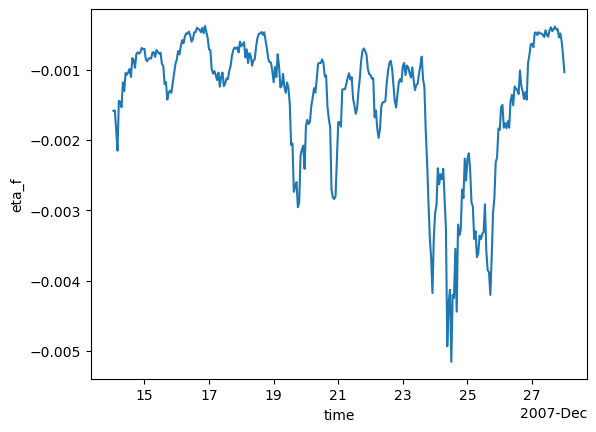

In [63]:

ds_etaf = compute_eta_f(Seta4,freqs4,t_eta4,-h_eta4)

ds_etaf[]
#ax.grid(True, which='both')

In [59]:
ds_etaf.time.values.shape

(336,)

In [58]:
t_eta4.shape

(336,)

#### Equation 3
$$
\bar{\eta}_i = \bar{h}_i - \bar{h}_f - (bt + c) + \bar{\eta}_f
$$

Steps to get this right:

1. Create function to compute $ \eta_f$ (Setdown at ref face)
2. build dependent variable on RHS of eq
3. construct design matrix 
4. **ignore the least squares fit (bt+c) for now**

Note: for a least squares fit you would do:
```python
## ------ build dependent variable and design matrix --------- ##

# build the dependent variable on the RHS of eq (3)
rhs = (h1_bar - hf_bar - eta_f).to_numpy()

# choose a time axis in days (any consistent unit works)
t = (h1_bar.index - h1_bar.index[0]).total_seconds().to_numpy() / 86400.0

# design matrix for [b, c] in bt + c
A = np.column_stack([t, np.ones_like(t)])

## ----------- least-squares solution -------------- ##
b, c = np.linalg.lstsq(A, rhs, rcond=None)[0]
print(f"b = {b:.4e} per day,  c = {c:.4f} m")

## Compute equation 3
eta_1 = h1_bar - hf_bar - (b*t + c) + eta_f
```


In [ ]:
## ------ Align Time Series and Build Time Axis------ ##

ds_etaf = compute_eta_f(Seta4, freqs4, t_sec, t4, h4)
eta_f = pd.Series(ds_etaf.eta_f, index=pd.to_datetime(t4_eta)).resample('6h').mean()
h1_bar = pd.Series(h1, index=pd.to_datetime(t1)).resample('6h').mean()
hf_bar = pd.Series(h4, index=pd.to_datetime(t4)).resample('6h').mean()
# find common timestamps between h1 and hf
idx = h1_bar.index.intersection(hf_bar.index)
h1_bar = h1_bar.loc[idx]
hf_bar = hf_bar.loc[idx]
eta_f = eta_f.loc[idx]

## ------ build dependent variable and design matrix --------- ##

# build the dependent variable on the RHS of eq (3)
rhs = (h1_bar - hf_bar - eta_f).to_numpy()

# choose a time axis in days (any consistent unit works)
t = (h1_bar.index - h1_bar.index[0]).total_seconds().to_numpy() / 86400.0

# design matrix for [b, c] in bt + c
A = np.column_stack([t, np.ones_like(t)])

## ----------- least-squares solution -------------- ##
b, c = np.linalg.lstsq(A, rhs, rcond=None)[0]
print(f"b = {b:.4e} per day,  c = {c:.4f} m")

## Compute equation 3
eta_1 = h1_bar - hf_bar - (b*t + c) + eta_f

b = -2.1638e-03 per day,  c = -4.6646 m


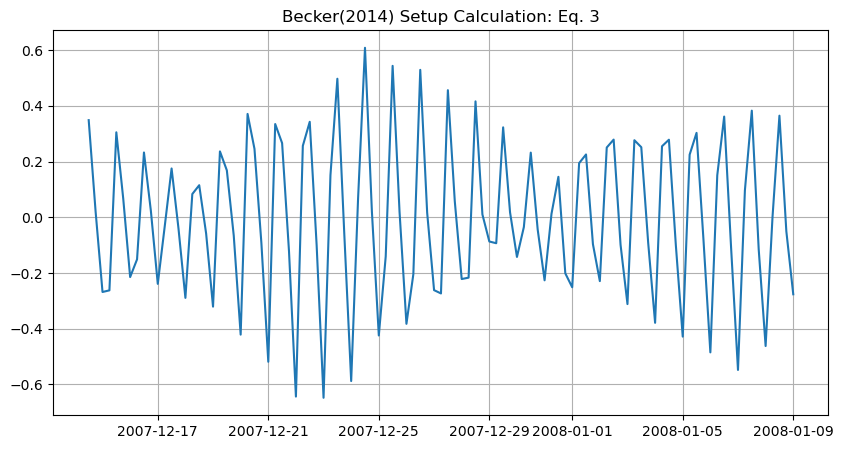

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(h1_bar.index, eta_1)
plt.title('Becker(2014) Setup Calculation: Eq. 3')
plt.grid(True)

In [ ]:
bursts4a = loadPressureData(Path("data/MoA48411.mat"))
Sensor4a = pd.DataFrame({
    'time': bursts4a.time,
    'h': bursts4a.depth_m,
    'p': bursts4a.pressure_pa
})
bursts4b = loadPressureData(Path("data/MoB48411.mat"))
Sensor4b = pd.DataFrame({
    'time': bursts4b.time,
    'h': bursts4b.depth_m,
    'p': bursts4b.pressure_pa
})


Sensor4a['time'].min(), Sensor4a['time'].max(), Sensor4b['time'].min(), Sensor4b['time'].max()


(Timestamp('2007-12-14 00:00:00'),
 Timestamp('2008-01-09 01:36:38.999998208'),
 Timestamp('2008-01-09 02:00:48.999998976'),
 Timestamp('2008-02-24 11:13:05.999994880'))

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr

def compute_eta_i_from_ds(
    ds_eta_f: xr.Dataset,
    h_i,
    h_i_time,
    *,
    align: str = "nearest",            # "nearest" or "interp"
    tolerance: str | None = "10min",   # only for nearest
    force_positive_depth: bool = True,
    return_new_ds: bool = True,
) -> xr.Dataset | xr.DataArray:

    if not isinstance(ds_eta_f, xr.Dataset):
        raise TypeError("ds_eta_f must be an xarray.Dataset.")
    for v in ("eta_f", "h_f"):
        if v not in ds_eta_f:
            raise ValueError(f"ds_eta_f missing '{v}'")
    if "time" not in ds_eta_f.coords:
        raise ValueError("ds_eta_f must have 'time' coordinate.")

    # --- target time from eta_f dataset ---
    target_time = pd.to_datetime(ds_eta_f["time"].values)

    # --- coerce h_i into a Series with its own time index ---
    h_i_arr = np.asarray(h_i, dtype=float)
    ti = pd.to_datetime(h_i_time)
    if getattr(ti, "tz", None) is not None:
        ti = ti.tz_convert("UTC").tz_localize(None)

    h_i_ser = pd.Series(h_i_arr, index=ti)

    # --- ✅ Intersect timestamps before aligning ---
    common_times = target_time.intersection(h_i_ser.index)

    # Subselect both to shared timestamps
    h_i_common = h_i_ser.loc[common_times]
    target_common = pd.to_datetime(common_times)

    # Now build DataArray for further xr operations
    h_i_da = xr.DataArray(
        h_i_common.values.astype(float),
        coords={"time": target_common.values.astype("datetime64[ns]")},
        dims=("time",),
        name="h_i"
    )

    # sort & combine duplicates
    h_i_da = h_i_da.sortby("time").groupby("time").mean()

    # --- align to dataset time using selected common times
    if align == "nearest":
        tol = None if tolerance is None else pd.to_timedelta(tolerance)
        if tol is None:
            h_i_on_face = h_i_da.sel(time=target_common, method="nearest")
        else:
            h_i_on_face = h_i_da.sel(time=target_common, method="nearest", tolerance=tol)
    elif align == "interp":
        h_i_on_face = h_i_da.interp(time=target_common)
    else:
        raise ValueError("align must be 'nearest' or 'interp'.")

    # --- depths from ds (subselect to matching time window) ---
    h_f = ds_eta_f["h_f"].sel(time=target_common)

    # --- enforce positive depth ---
    if force_positive_depth:
        h_i_on_face = np.abs(h_i_on_face)
        h_f = np.abs(h_f)

    h_i_on_face = xr.where(h_i_on_face > 0.0, h_i_on_face, np.nan)
    h_f = xr.where(h_f > 0.0, h_f, np.nan)

    # --- compute eta_i ---
    eta_i = (ds_eta_f["eta_f"].sel(time=target_common) +
             (h_i_on_face - h_f)).rename("eta_i")

    eta_i.attrs.update({
        "equation": "eta_i = eta_f + (h_i - h_f)",
        "aligned": align,
        "tolerance": tolerance,
    })

    if return_new_ds:
        out = ds_eta_f.sel(time=target_common).copy()
        out["h_i"] = h_i_on_face
        out["eta_i"] = eta_i
        return out
    else:
        return eta_i


#### Sig Wave Height Analysiz

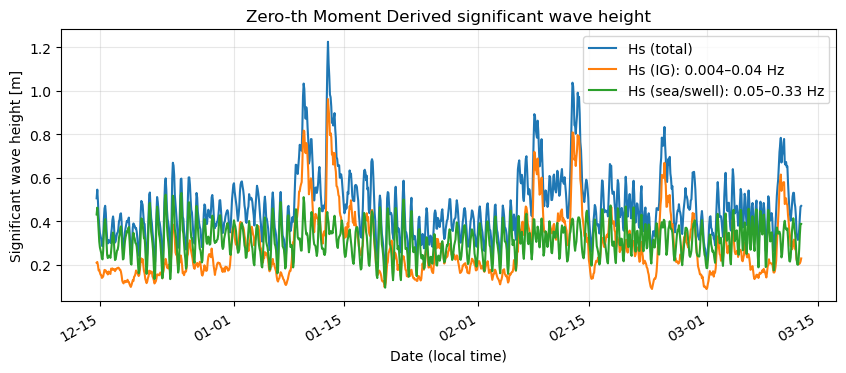

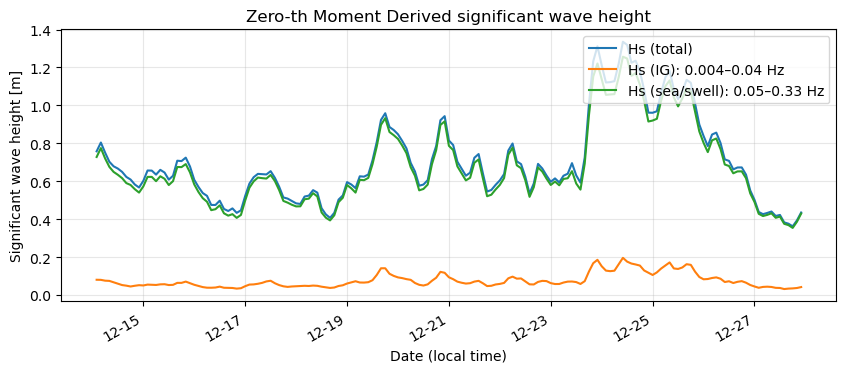

In [ ]:
## ---- convert negative arrays to pos ---- ##
#h4 = -h4 
# h_eta4 = -h_eta4
# h4b = -h4b 
# h_eta4b =  -h_eta4b


Hs1, Hs1ig, Hs1ss, ____ , ____, tHs1 = sig_wave_height (Seta1, freqs1, t1_spec, t1, h1, (0.04,0.4))

Hs4, Hs4ig, Hs4ss, ____ , ____, tHs4 = sig_wave_height (Seta4, freqs4, t4_spec, t4, h4, (0.04,0.4))

#Hs6, Hs6ig, Hs6ss, ____ , ____, tHs6 = sig_wave_height (Seta6, freqs6, t6_spec, t6, h6, (0.04,0.4))




# def sig_wave_height(
#     Seta: np.ndarray,
#     freqs: np.ndarray,
#     t_spec: np.ndarray,
#     t1: np.ndarray,
#     h1: np.ndarray,
#     bands,
#     *,
#     depth_interp: np.ndarray | None = None,
#     dataviz: bool = True,

#     return hs_tot, hs_ig, hs_ss, hs_bands, tp_ss, time_cente

In [ ]:
h6 = (
    pd.Series(h6, index=pd.to_datetime(t6))
    .interpolate(method="linear", limit=20, limit_direction="both")
    .to_numpy()
    )



# INPUT VALUES
fs = 1
nperseg = 14400 # 2 hr windows
noverlap = nperseg * 0.75 # 75% overlap

freqs6, t6_spec, Spp6 = spectrogram(p6_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = noverlap, detrend = 'linear', scaling = 'density',mode='psd', )
Seta6, t_eta6, h_eta6 = Spp_to_Seta(Spp6, freqs6, t6_spec, t6, h6)

mask_total = freqs6 > 0.0
mask_ss = (freqs6 >= 0.05) & (freqs6 <= 0.5)
mask_ig = (freqs6 >= 0.004) & (freqs6 <= 0.049)

omega = 2.0 * np.pi * freqs6

hs_tot: list[float] = []
hs_ss: list[float] = []
hs_ig: list[float] = []
tp_ss: list[float] = []

for col, depth_val in enumerate(h6):
    seta = Seta6[:, col]

    def spectral_moment(mask: np.ndarray) -> float:
        if not np.any(mask):
            return 0.0
        return float(np.trapz(seta[mask], freqs6[mask]))

    m0_total = spectral_moment(mask_total)
    m0_sea_swell = spectral_moment(mask_ss)
    m0_ig = spectral_moment(mask_ig)

    hs_tot.append(4.0 * np.sqrt(max(m0_total, 0.0)))
    hs_ss.append(4.0 * np.sqrt(max(m0_sea_swell, 0.0)))
    hs_ig.append(4.0 * np.sqrt(max(m0_ig, 0.0)))

    if np.any(mask_ss):
        ss_slice = seta[mask_ss]
        if np.all(np.isfinite(ss_slice)) and np.nanmax(ss_slice) > 0.0:
            fp = freqs6[mask_ss][np.nanargmax(ss_slice)]
            tp_ss.append(1.0 / fp if fp > 0.0 else np.nan)
        else:
            tp_ss.append(np.nan)
    else:
        tp_ss.append(np.nan)

hs_tot = np.asarray(hs_tot)
hs_ss = np.asarray(hs_ss)
hs_ig = np.asarray(hs_ig)


IndexError: index 802 is out of bounds for axis 1 with size 802

In [ ]:
1/0.049

20.408163265306122

In [ ]:

    Parameters
    ----------
    Seta : np.ndarray
        Surface elevation spectra (m^2/Hz) with shape (n_freqs, n_windows).
    freqs : np.ndarray
        Frequency vector corresponding to rows of ``Spp`` [Hz].
    t_spec : np.ndarray
        Spectrogram time centers in seconds since the start of the record.
    t1 : np.ndarray
        Native datetime64 array for the 1 Hz series.
    h1 : np.ndarray
        Raw hydrostatic depth series (may contain NaNs).
    bands : list
        desired inputs of frequency bands to be integrated     
    depth_interp : np.ndarray, optional
        Pre-interpolated depth series matching ``h1`` (1 Hz). If not supplied, it is built via linear interpolation.
    dataviz : bool, optional
        When True, generate a quick-look plot of the Hs time series.

    Returns
    -------
    hs_tot, hs_ig, hs_ss, hs_input, tp_ss, time_centers : tuple of np.ndarray
        Bulk metrics for each spectrogram window and the corresponding datetime64 centers.
    """
    RHO = 1025.0


    # spectrogram centers as datetime64
    t0 = np.array(t1[0], dtype="datetime64[ns]")
    time_offsets = (t_spec * 1e9).astype("timedelta64[ns]")
    time_centers = t0 + time_offsets

    seconds_full = (t1 - t1[0]) / np.timedelta64(1, "s")
    depth_at_centers = np.interp(t_spec, seconds_full, depth_interp)

    mask_total = freqs > 0.0
    mask_ss = (freqs >= 0.05) & (freqs <= 0.33)
    mask_ig = (freqs >= 0.004) & (freqs <= 0.04)
    mask_input = (freqs >= bands[0]) & (freqs <= bands[1])

    omega = 2.0 * np.pi * freqs

    hs_tot: list[float] = []
    hs_ss: list[float] = []
    hs_ig: list[float] = []
    hs_bands: list[float] = []
    tp_ss: list[float] = []


    for col, depth_val in enumerate(depth_at_centers):
        seta = Seta[:, col]

        def spectral_moment(mask: np.ndarray) -> float:
            if not np.any(mask):
                return 0.0
            return float(np.trapz(seta[mask], freqs[mask]))

        m0_total = spectral_moment(mask_total)
        m0_sea_swell = spectral_moment(mask_ss)
        m0_ig = spectral_moment(mask_ig)
        m0_input = spectral_moment(mask_input)

        hs_tot.append(4.0 * np.sqrt(max(m0_total, 0.0)))
        hs_ss.append(4.0 * np.sqrt(max(m0_sea_swell, 0.0)))
        hs_ig.append(4.0 * np.sqrt(max(m0_ig, 0.0)))
        hs_bands.append(4.0 * np.sqrt(max(m0_input, 0.0)))

        if np.any(mask_ss):
            ss_slice = seta[mask_ss]
            if np.all(np.isfinite(ss_slice)) and np.nanmax(ss_slice) > 0.0:
                fp = freqs[mask_ss][np.nanargmax(ss_slice)]
                tp_ss.append(1.0 / fp if fp > 0.0 else np.nan)
            else:
                tp_ss.append(np.nan)
        else:
            tp_ss.append(np.nan)

    hs_tot = np.asarray(hs_tot)
    hs_ss = np.asarray(hs_ss)
    hs_ig = np.asarray(hs_ig)
    hs_bands = np.asarray(hs_bands)
    tp_ss = np.asarray(tp_ss)

    if dataviz:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(time_centers, hs_tot, label="Hs (total)")
        ax.plot(time_centers, hs_ig, label="Hs (IG): 0.004–0.04 Hz")
        ax.plot(time_centers, hs_ss, label="Hs (sea/swell): 0.05–0.33 Hz")
        ax.set_ylabel("Significant wave height [m]")
        ax.set_xlabel("Date (local time)")
        ax.set_title("Zero-th Moment Derived significant wave height")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
        fig.autofmt_xdate()
        plt.show()

    return hs_tot, hs_ig, hs_ss, hs_bands, tp_ss, time_centers

UFuncTypeError: ufunc 'multiply' cannot use operands with types dtype('<M8[ns]') and dtype('float64')

In [ ]:
import numpy as np
import pandas as pd

# assume these Series/arrays are already aligned on time
# hi_bar: mean water level at inner sensor (sensor 1)
# hf_bar: mean water level at reef face (sensor 4)
# eta_f: setup/setdown from the reef-face transfer (same cadence)
# time_index: datetime index shared by all three (after resample)

# build the dependent variable on the RHS of eq (3)
rhs = (hi_bar - hf_bar - eta_f).to_numpy()

# choose a time axis in days (any consistent unit works)
t = (time_index - time_index[0]).total_seconds().to_numpy() / 86400.0

# design matrix for [b, c] in bt + c
A = np.column_stack([t, np.ones_like(t)])

# least-squares solution
b, c = np.linalg.lstsq(A, rhs, rcond=None)[0]
print(f"b = {b:.4e} per day,  c = {c:.4f} m")


In [ ]:
drift = b * t + c
eta_i = hi_bar - hf_bar - drift + eta_f
